In [81]:
## libraries to install ##
#!pip install seaborn pandas matplotlib numpy tabulate plotly

import os
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
from matplotlib.gridspec import GridSpec

from hbn.constants import Defaults  
from hbn.visualization import make_tables, visualize as vis, raw_scores

import plotly.io as pio
pio.renderers.default='notebook'

%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
vis.plotting_style()

In [50]:
# ## load data

df_reading = raw_scores.get_data(assessment='Child', 
                      cols_to_filter=['WIAT,WIAT_Word_Raw', 'WIAT,WIAT_RC_Raw', 'TOWRE,TOWRE_PDE_Raw', 'TOWRE,TOWRE_SWE_Raw']
                      )
df_reading = df_reading.groupby(['Identifiers', 'DX_Reading']).first().reset_index()
df_reading = df_reading[(df_reading['DX_Reading'].isin(['Reading (all comorbid.)', 'Reading (no comorbid.)'])) & 
                        (df_reading['Age_round'].isin(np.arange(6,18)))]


### Raw Scores - TOWRE and WIAT

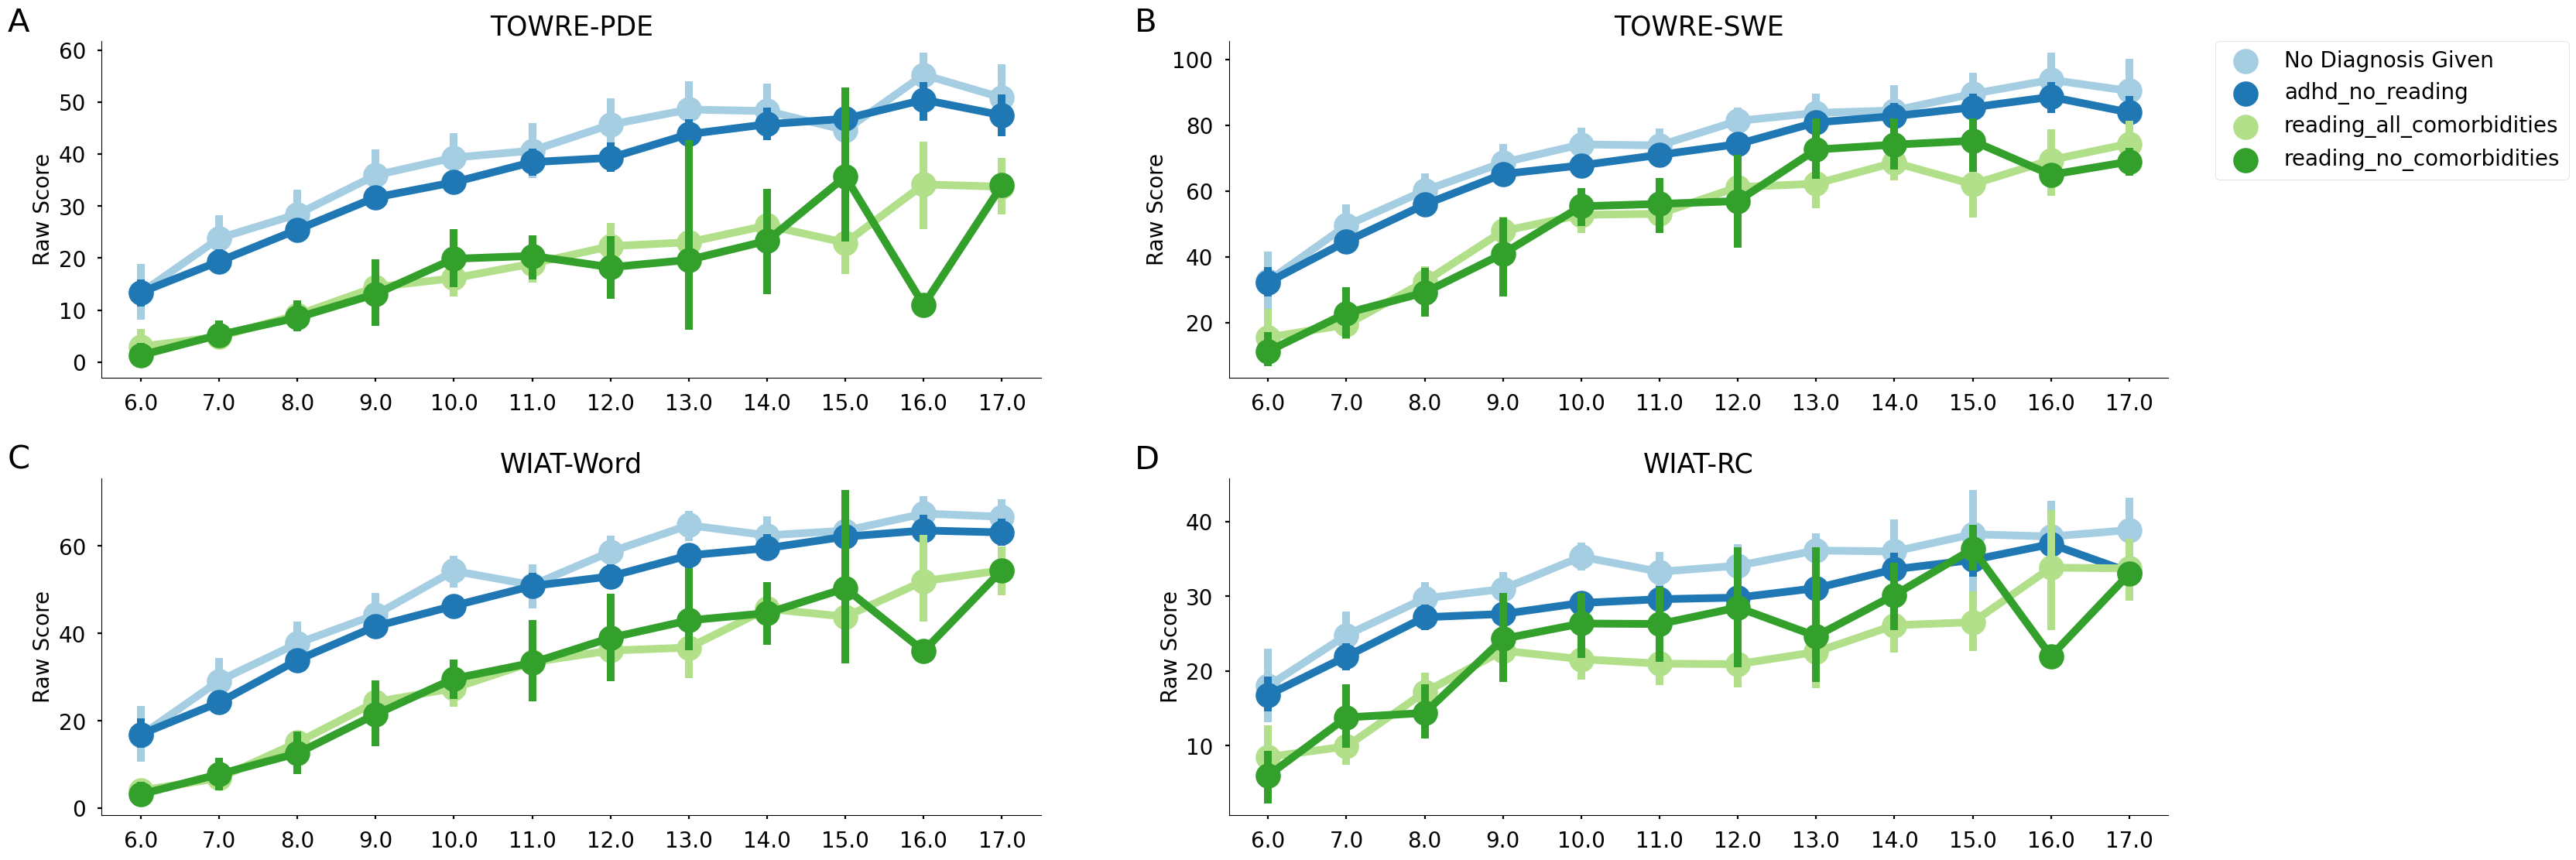

In [22]:

# # plot
vis.plotting_style()
fig = plt.figure(figsize=(4,5))
gs = GridSpec(2, 2, figure=fig)

plot_dict = {'A': ['TOWRE,TOWRE_PDE_Raw', (0,0), False, 'TOWRE-PDE'],
            'B': ['TOWRE,TOWRE_SWE_Raw', (0,1), True, 'TOWRE-SWE'],
            'C': ['WIAT,WIAT_Word_Raw', (1,0), False, 'WIAT-Word'],
            'D': ['WIAT,WIAT_RC_Raw', (1,1), False, 'WIAT-RC'],
            # 'E': ['WIAT,WIAT_LCRV_Raw', (2,0), True, 'WIAT-LCRV'],
            # 'F': ['WIAT,WIAT_LCODC_Raw', (2,1), True, 'WIAT-LCODC'],
            }

for i, (key, value) in enumerate(plot_dict.items()):
    ax = fig.add_subplot(gs[plot_dict[key][1]])
    vis.pointplot(x='Age_round', y=value[0], hue='DX_Reading', data=df_reading, ax=ax, subplot=key, title=value[3], legend=value[2])
    
fig.subplots_adjust(left=0.125, bottom=0.001, right=6.8, top=2.0, wspace=.2, hspace=.3)
# fig.savefig(os.path.join(Defaults.FIG_DIR, f'raw-scores-readers-ages-male-female-No-Diagnosis.png'), bbox_inches='tight')


### Raw scores - TOWRE and WIAT (race differences)

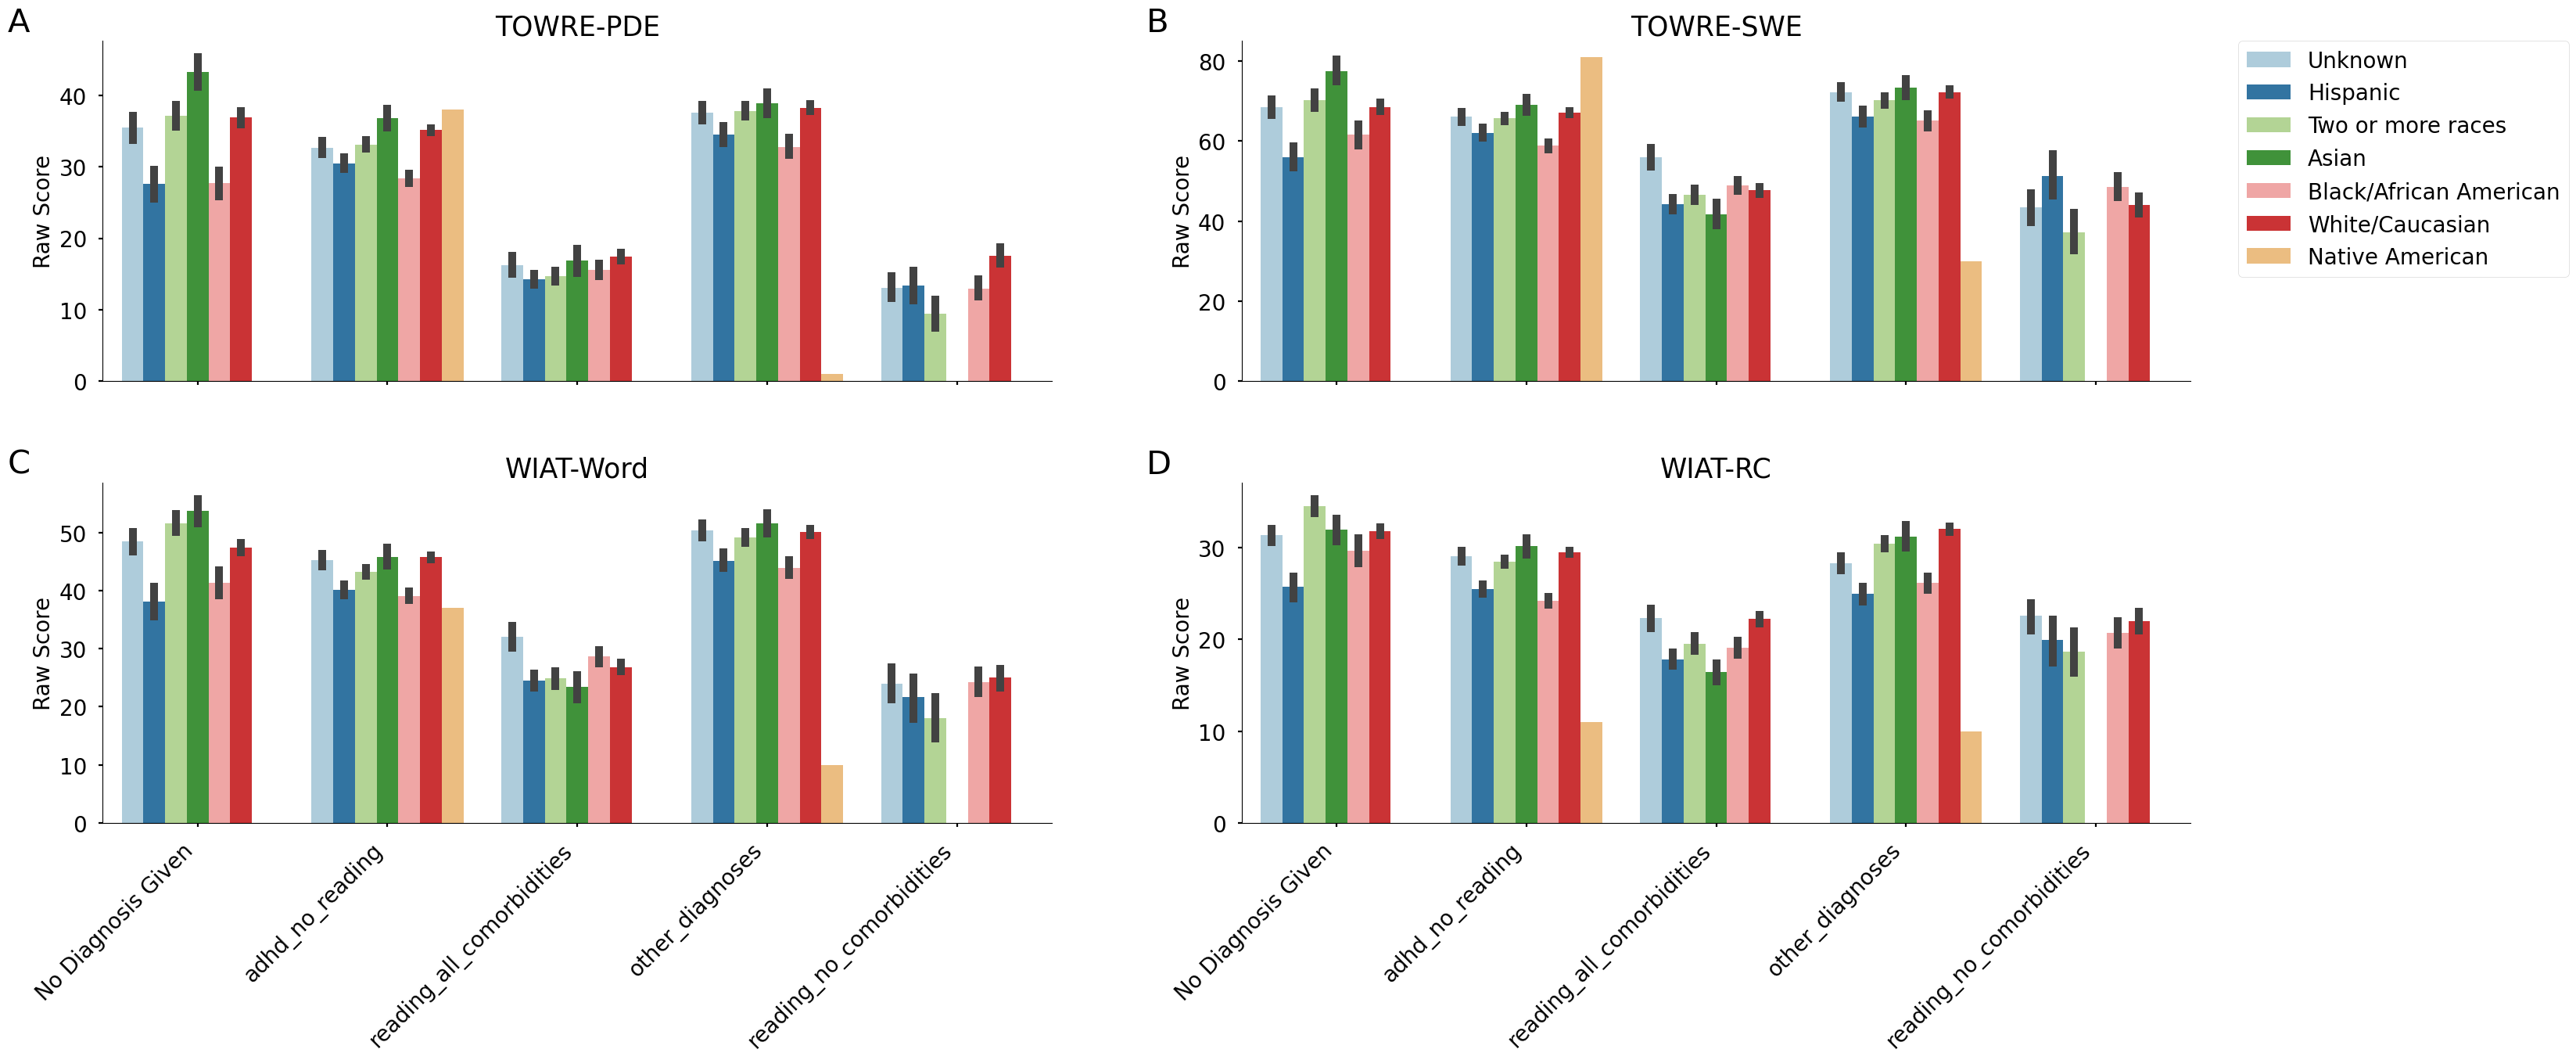

In [20]:

# plot
vis.plotting_style()
fig = plt.figure(figsize=(4,5))
gs = GridSpec(2, 2, figure=fig)

plot_dict = {'A': ['TOWRE,TOWRE_PDE_Raw', (0,0), False, 'TOWRE-PDE', False],
            'B': ['TOWRE,TOWRE_SWE_Raw', (0,1), True, 'TOWRE-SWE', False],
            'C': ['WIAT,WIAT_Word_Raw', (1,0), False, 'WIAT-Word', True],
            'D': ['WIAT,WIAT_RC_Raw', (1,1), False, 'WIAT-RC', True],
            # 'E': ['WIAT,WIAT_LCRV_Raw', (2,0), True, 'WIAT-LCRV'],
            # 'F': ['WIAT,WIAT_LCODC_Raw', (2,1), True, 'WIAT-LCODC'],
            }

for i, (key, value) in enumerate(plot_dict.items()):
    ax = fig.add_subplot(gs[plot_dict[key][1]])
    vis.barplot(x='DX_Reading', y=value[0], hue='PreInt_Demos_Fam,Child_Race_cat', data=df_reading, ax=ax, subplot=key, title=value[3], legend=value[2], xticks=value[4])
    
fig.subplots_adjust(left=0.125, bottom=0.001, right=6.8, top=2.0, wspace=.2, hspace=.3)
# fig.savefig(os.path.join(Defaults.FIG_DIR, f'raw-scores-readers-ages-male-female-No-Diagnosis.png'), bbox_inches='tight')



### Is anyone being misdiagnosed? 

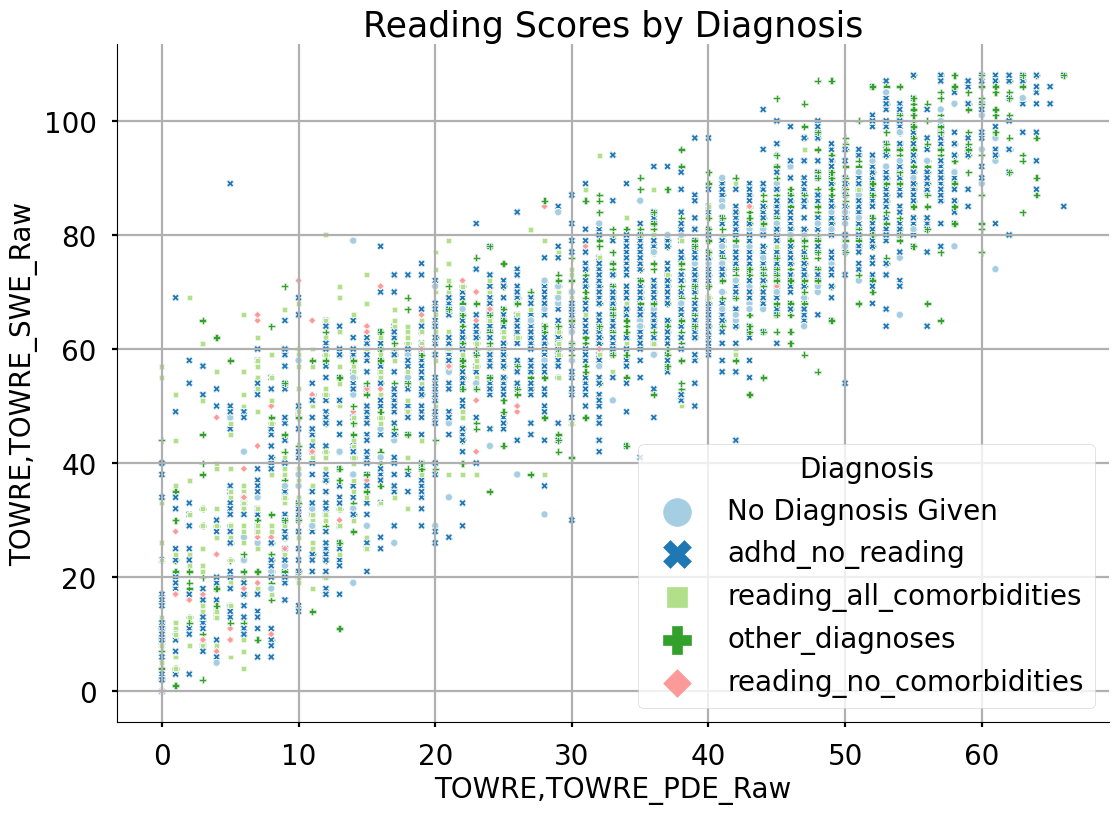

In [21]:
x_data = 'TOWRE,TOWRE_PDE_Raw'
y_data = 'TOWRE,TOWRE_SWE_Raw'

# x_data ='WIAT,WIAT_RC_Raw'
# y_data = 'WIAT,WIAT_Word_Raw'

sns.scatterplot(
    x=df_reading[x_data], 
    y=df_reading[y_data], 
    hue='DX_Reading', 
    style='DX_Reading',
    data=df_reading,
    s=25
    )

plt.xlabel(x_data)
plt.ylabel(y_data)
plt.title('Reading Scores by Diagnosis')
plt.legend(title='Diagnosis')
plt.grid(True)
plt.show()


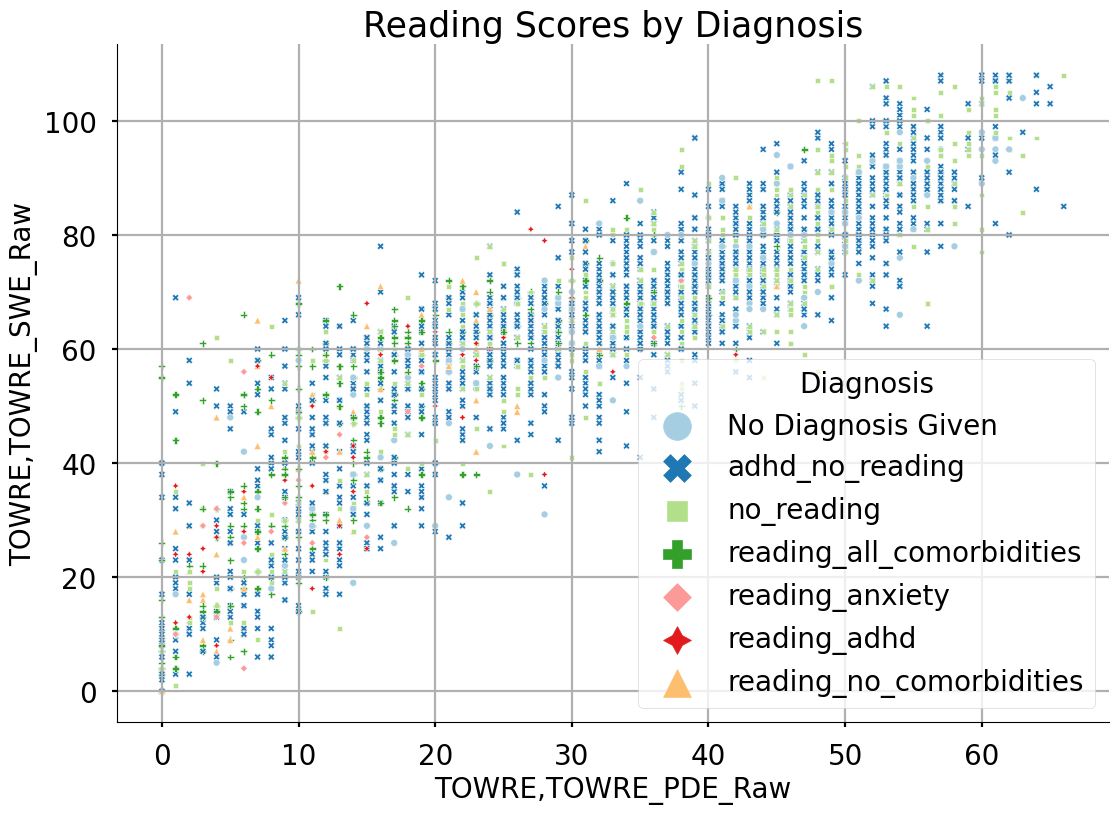

In [44]:
x_data = 'TOWRE,TOWRE_PDE_Raw'
y_data = 'TOWRE,TOWRE_SWE_Raw'

# x_data ='WIAT,WIAT_RC_Raw'
# y_data = 'WIAT,WIAT_Word_Raw'

sns.scatterplot(
    x=df_reading[x_data], 
    y=df_reading[y_data], 
    hue='DX_Reading', 
    style='DX_Reading',
    data=df_reading,
    s=25
    )

plt.xlabel(x_data)
plt.ylabel(y_data)
plt.title('Reading Scores by Diagnosis')
plt.legend(title='Diagnosis')
plt.grid(True)
plt.show()


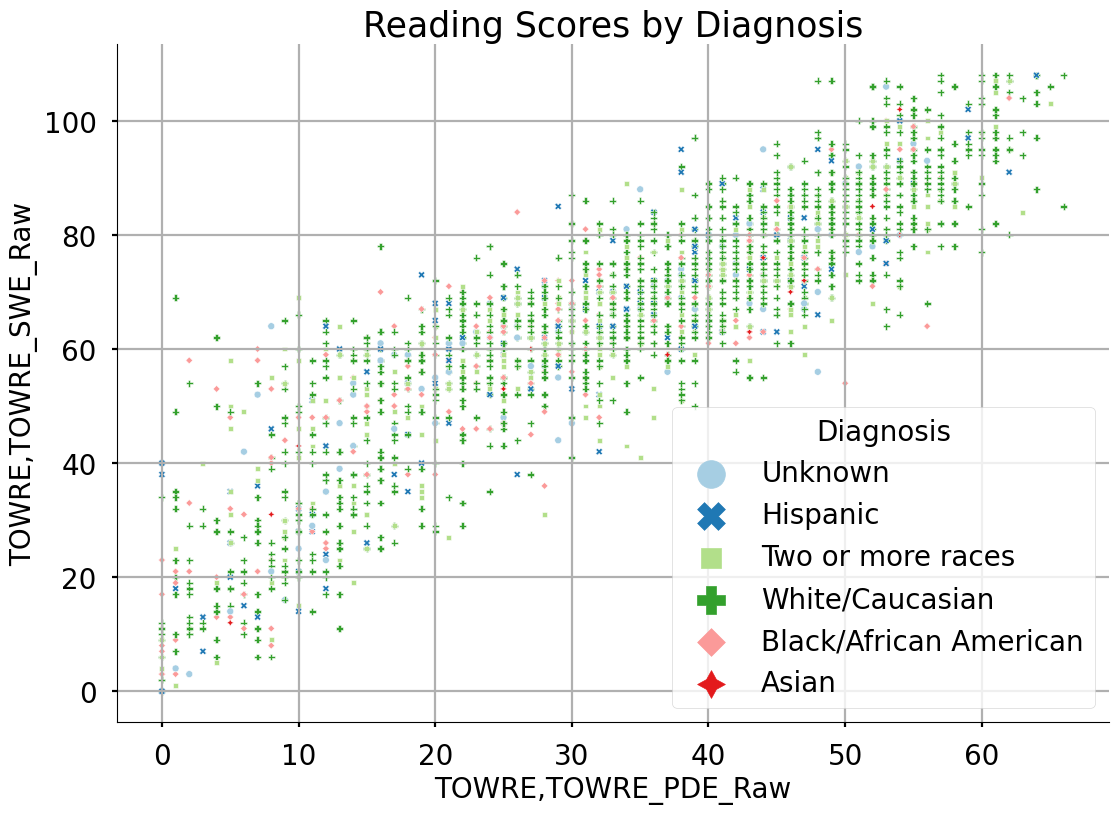

(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, 'Unknown'),
  Text(1, 0, 'Hispanic'),
  Text(2, 0, 'Two or more races'),
  Text(3, 0, 'White/Caucasian'),
  Text(4, 0, 'Black/African American'),
  Text(5, 0, 'Asian')])

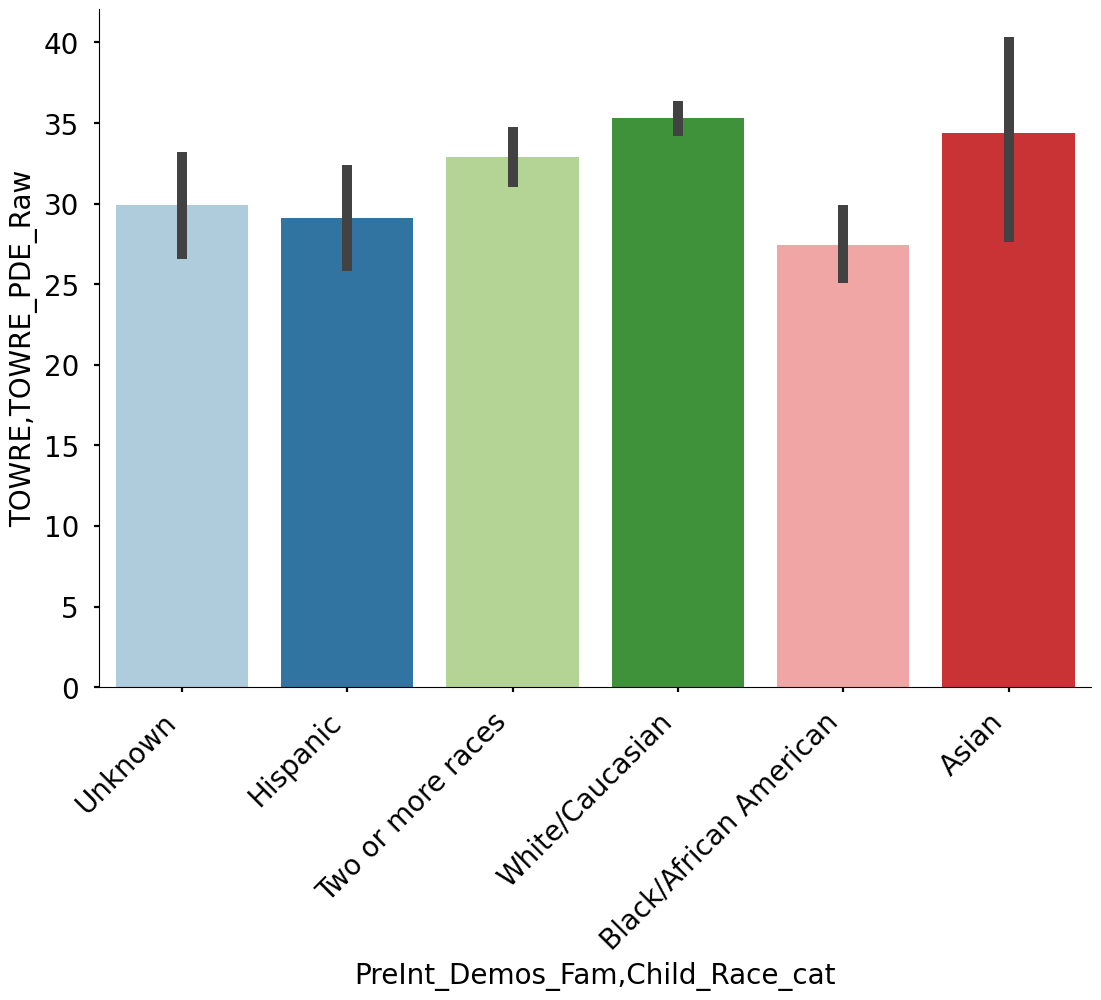

In [55]:
x_data = 'TOWRE,TOWRE_PDE_Raw'
y_data = 'TOWRE,TOWRE_SWE_Raw'

# x_data ='WIAT,WIAT_RC_Raw'
# y_data = 'WIAT,WIAT_Word_Raw'

sns.scatterplot(
    x=df_reading[x_data], 
    y=df_reading[y_data], 
    hue='PreInt_Demos_Fam,Child_Race_cat', 
    style='PreInt_Demos_Fam,Child_Race_cat',
    data=df_reading,
    s=25
    )

plt.xlabel(x_data)
plt.ylabel(y_data)
plt.title('Reading Scores by Diagnosis')
plt.legend(title='Diagnosis')
plt.grid(True)
plt.show()

sns.barplot(x='PreInt_Demos_Fam,Child_Race_cat', y='TOWRE,TOWRE_PDE_Raw', data=df_filter)
plt.xticks(rotation=45, ha='right');


### Raw scores - TOWRE and WIAT (sex differences)

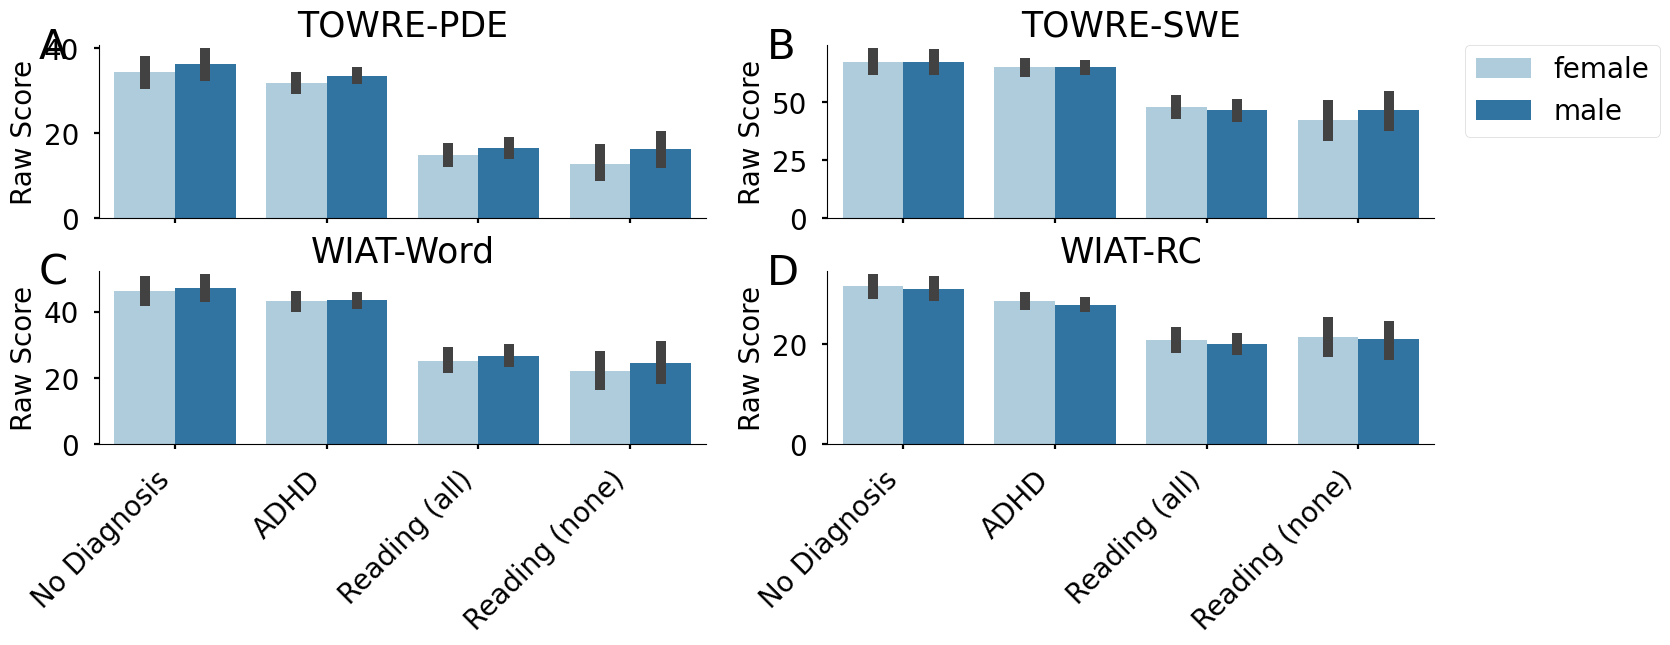

In [235]:

# plot
vis.plotting_style()
fig = plt.figure(figsize=(2,2))
gs = GridSpec(2, 2, figure=fig)

plot_dict = {'A': ['TOWRE,TOWRE_PDE_Raw', (0,0), False, 'TOWRE-PDE', False],
            'B': ['TOWRE,TOWRE_SWE_Raw', (0,1), True, 'TOWRE-SWE', False],
            'C': ['WIAT,WIAT_Word_Raw', (1,0), False, 'WIAT-Word', True],
            'D': ['WIAT,WIAT_RC_Raw', (1,1), False, 'WIAT-RC', True],
            # 'E': ['WIAT,WIAT_LCRV_Raw', (2,0), True, 'WIAT-LCRV'],
            # 'F': ['WIAT,WIAT_LCODC_Raw', (2,1), True, 'WIAT-LCODC'],
            }

for i, (key, value) in enumerate(plot_dict.items()):
    ax = fig.add_subplot(gs[plot_dict[key][1]])
    vis.barplot(x='DX_Reading', y=value[0], hue='Sex', data=df_reading, ax=ax, subplot=key, title=value[3], legend=value[2], xticks=value[4])
    
fig.subplots_adjust(left=0.125, bottom=0.001, right=6.8, top=2.0, wspace=.2, hspace=.3)
# fig.savefig(os.path.join(Defaults.FIG_DIR, f'raw-scores-readers-ages-male-female-No-Diagnosis.png'), bbox_inches='tight')


### Internalizing and Externalizing

In [26]:

# get data
df = raw_scores.load_parent_child_teacher(key='Int', dx_to_include=['Reading (all comorbid.)', 'Reading (no comorbid.)', 'No Diagnosis', 'ADHD'])
df_melt = raw_scores.melt_dataframe(df, data='Internalizing', key='Int')

# plot facetgrid
vis.plot_facetgrid(df_melt, data='Internalizing')


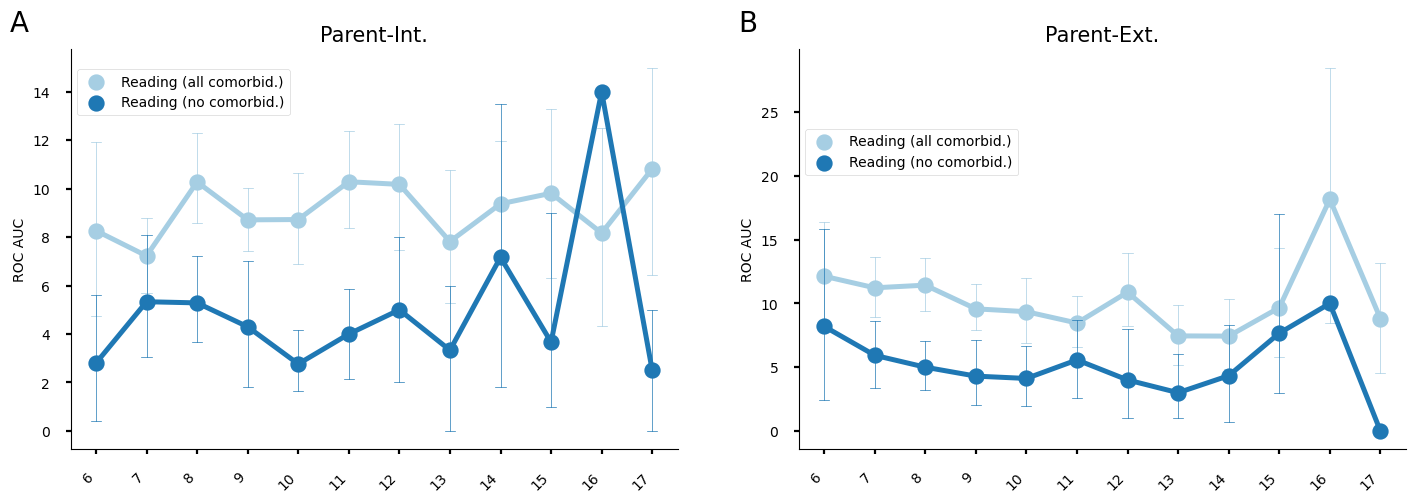

In [85]:
df = raw_scores.load_parent_child_teacher(key=['Int', 'Ext'], dx_to_include=['Reading (all comorbid.)', 'Reading (no comorbid.)'])

# # plot
vis.plotting_style()
fig = plt.figure(figsize=(2,2))
gs = GridSpec(1, 2, figure=fig)

plot_dict = {'A': ['CBCL,CBCL_Int', (0,0), True, 'Parent-Int.', (.01, .95)],
            'B': ['CBCL,CBCL_Ext', (0,1), True, 'Parent-Ext.', (.01,.8)],
            }

for i, (key, value) in enumerate(plot_dict.items()):
    ax = fig.add_subplot(gs[plot_dict[key][1]])
    vis.pointplot(x='Age_round', y=value[0], hue='DX_Reading', 
                    data=df, ax=ax, ylim=None, subplot=key, 
                    bbox_to_anchor=value[4],
                    title=value[3], legend=value[2])
    
fig.subplots_adjust(left=0.125, bottom=0.001, right=6.8, top=2.0, wspace=.2, hspace=.3)
fig.savefig(os.path.join(Defaults.FIG_DIR, f'Supp2.png'), bbox_inches='tight')
